In [27]:
# 1. 导库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# PassengerId,Survived,Pclass,Name, Sex,  Age, SibSp,  Parch, Ticket, Fare,Cabin,Embarked
# 乘客身份、    幸存、    P舱、   姓名、性别、年龄、社会等级、 乘客、 机票、     票价、客舱、已登机

In [28]:
# 2. 加载数据并查看
df = pd.read_csv('data/titanic_data.csv')
print("数据集形状:", df.shape)
print("\n前5行数据:")
display(df.head())
print("\n数据基本信息:")
df.info()
print("\n数值型数据统计:")
display(df.describe())

数据集形状: (891, 12)

前5行数据:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

数值型数据统计:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
# 3.数据清洗
# 3.1 缺失值处理
print("\n缺失值统计:")
print(df.isnull().sum())
df['Age'] = df['Age'].fillna(df['Age'].median())        # 用中位数填充年龄
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])    # 用众数填充登机口
df = df.drop(['Cabin'], axis=1)         # 删除Cabin列（船舱号）
# 删除无关列
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)


# 3.2 异常值处理（以Fare票价为例）
# 使用IQR（四分位距）方法检测异常值
Q1 = df['Fare'].quantile(0.25)  # 第一四分位数（25%位置的值）
Q3 = df['Fare'].quantile(0.75)  # 第三四分位数（75%位置的值）
IQR = Q3 - Q1  # 四分位距，衡量数据的离散程度

# 定义正常值范围：[Q1 - 1.5×IQR, Q3 + 1.5×IQR]
# 超出此范围的值被视为异常值
lower_bound = Q1 - 1.5 * IQR  # 下界
upper_bound = Q3 + 1.5 * IQR  # 上界
df = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]


缺失值统计:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


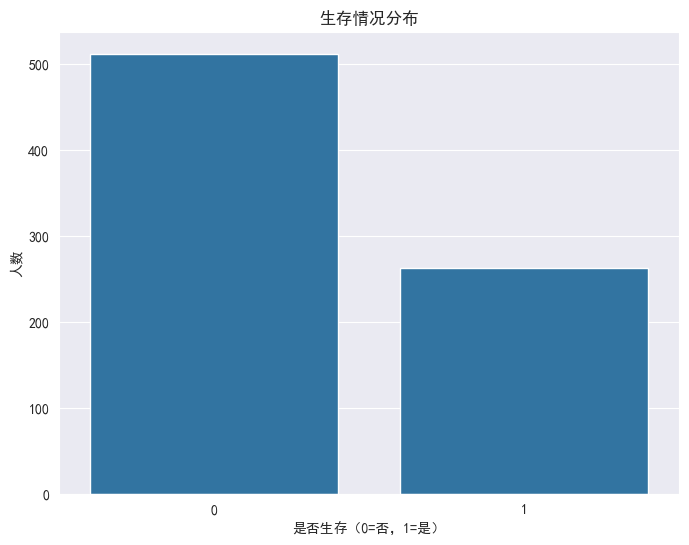

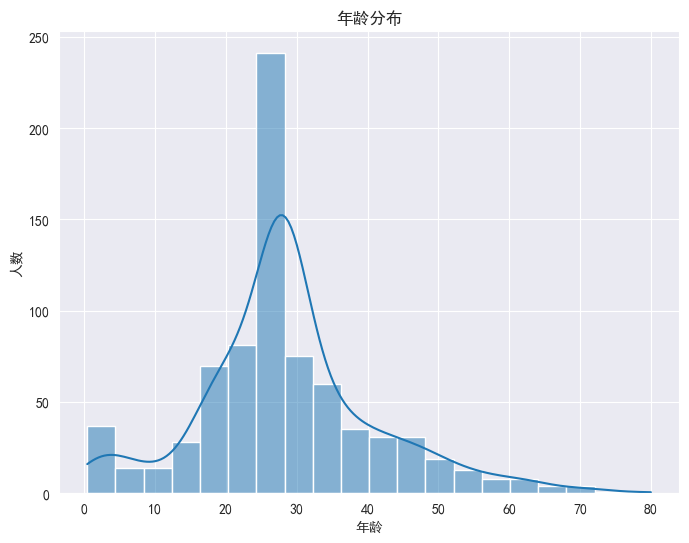

In [30]:
# 4. 单变量分析
# df.info()
# 4.1 生存情况分布
plt.figure(figsize=(8, 6))
# seaborn计数柱状图, x='Survived': 横轴为Survived列（取值0和1）
sns.countplot(x='Survived', data=df)
plt.title('生存情况分布')  # 设置图表标题
plt.xlabel('是否生存（0=否，1=是）')  # 设置x轴标签
plt.ylabel('人数')  # 设置y轴标签
plt.savefig('./images/survival_dist.png', dpi=300, bbox_inches='tight')
plt.show()  # 显示图表

# 观察要点：
# - 幸存者(1)和遇难者(0)的数量对比
# - 通常幸存者约38%，遇难者约62%，存在类别不平衡问题


# 4.2 年龄分布
plt.figure(figsize=(8, 6))
# histplot: 直方图 + 核密度估计
# bins=20: 将年龄范围分成20个等宽区间
# kde=True: 绘制核密度估计曲线（平滑的分布曲线）
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('年龄分布')
plt.xlabel('年龄')
plt.ylabel('人数')
plt.savefig('./images/age_dist.png', dpi=300, bbox_inches='tight')
plt.show()

# 观察要点：
# - 分布形态：不太对称,相对左偏
# - 峰值位置：20 - 30 之间
# - 范围：小几岁到70多岁


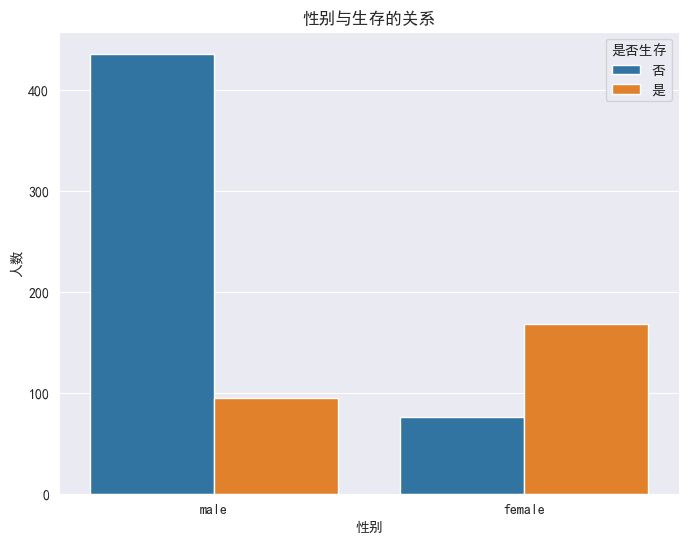

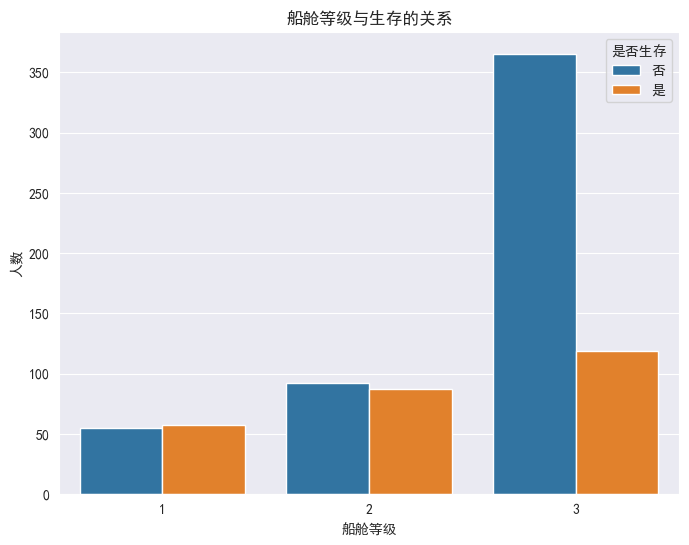

In [31]:
# 5. 双变量分析
# 5.1 性别与生存的关系
plt.figure(figsize=(8, 6))
# x='Sex': 横轴为性别（male/female）
# hue='Survived': 按生存状态分组着色，生成分组柱状图
# 每个性别下，会有两个柱子（幸存/遇难），用不同颜色区分
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('性别与生存的关系')
plt.xlabel('性别')
plt.ylabel('人数')
plt.legend(title='是否生存', labels=['否', '是'])  # 显示图例
plt.savefig('./images/gender_survival.png', dpi=300, bbox_inches='tight')
plt.show()

# 典型发现：
# 女性幸存率远高于男性（妇孺优先原则）

# 5.2 船舱等级与生存的关系
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('船舱等级与生存的关系')
plt.xlabel('船舱等级')
plt.ylabel('人数')
plt.legend(title='是否生存', labels=['否', '是'])  # 显示图例
plt.savefig('./images/class_survival.png', dpi=300, bbox_inches='tight')
plt.show()

# 典型发现：
# 头等舱幸存率最高，三等舱最低（社会阶层影响生存机会）

<Figure size 1000x600 with 0 Axes>

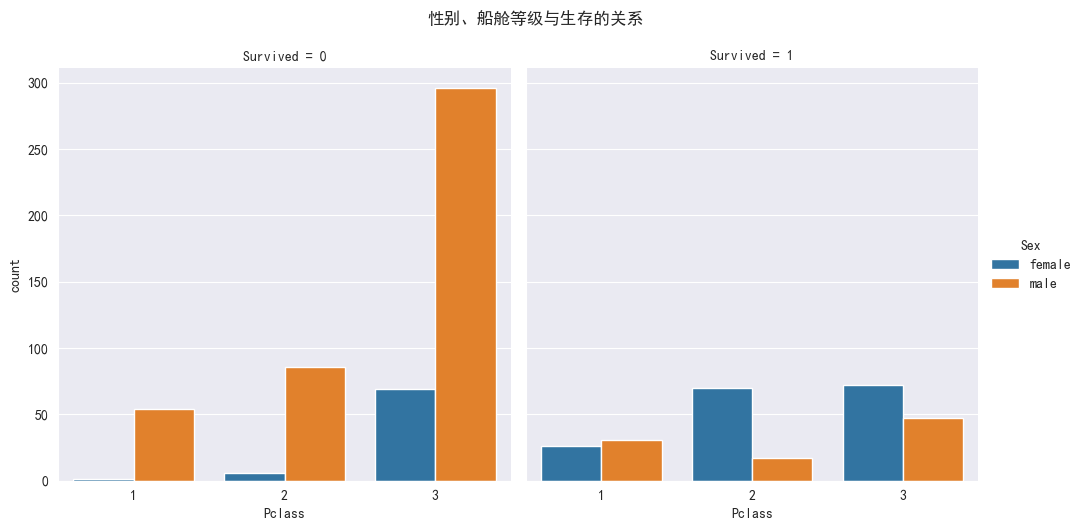

In [32]:
# 6. 多变量分析
# 6.1 性别、船舱等级与生存的关系
plt.figure(figsize=(10, 6))
# catplot: seaborn分类图，是高级接口，可以创建多种分类图
# x='Pclass': 横轴为船舱等级
# hue='Sex': 用颜色区分性别
# col='Survived': 关键参数！按是否生存拆分成多个子图（col=列方向）
#   - 左侧子图: Survived=0（遇难者）
#   - 右侧子图: Survived=1（幸存者）
# kind='count': 柱状图显示计数（也可以是'bar'、'box'等）
sns.catplot(x='Pclass', hue='Sex', col='Survived', data=df, kind='count')
plt.suptitle('性别、船舱等级与生存的关系', y=1.05)  # 设置总标题
plt.savefig('./images/gender_class_survival.png', dpi=300, bbox_inches='tight')
plt.show()

# 这个图能回答：
# "在幸存者中，不同船舱等级下男女的分布如何？"
# "在遇难者中，情况又如何？"

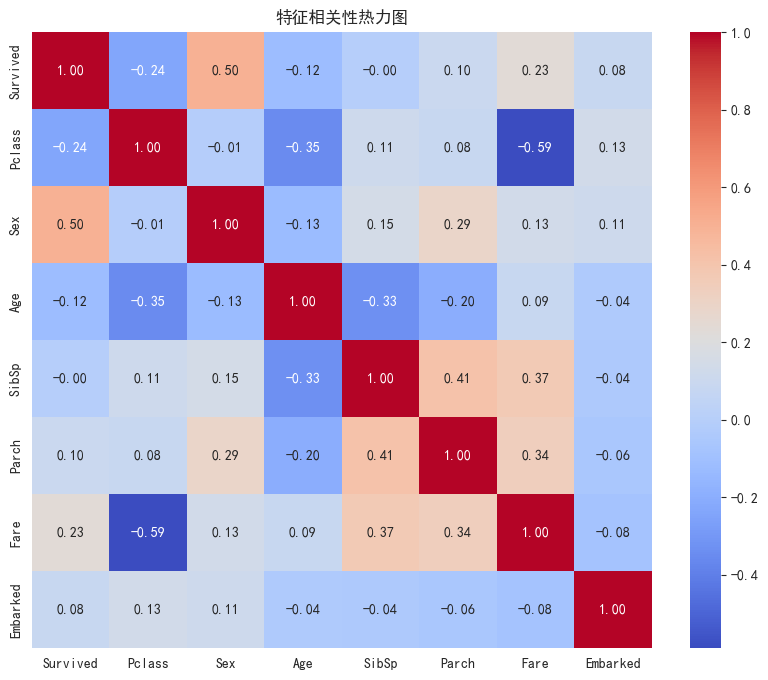

In [33]:
# 7. 相关性分析（计算特征间的相关系数）
# 7.1 将分类变量转换为数值型（因为corr()只能计算数值列）
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 7.2 绘制相关性热力图
plt.figure(figsize=(10, 8))  # 设置图形大小
# df.corr(): 计算所有数值列的相关系数矩阵（皮尔逊相关系数）
# annot=True: 在热力图格子中显示数值
# cmap='coolwarm': 颜色映射方案
#   - 红色: 正相关（一个增加，另一个也增加）
#   - 蓝色: 负相关（一个增加，另一个减少）
#   - 白色: 接近0相关
# fmt='.2f': 数值显示格式（2位小数）
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('特征相关性热力图')
plt.savefig('./images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 相关系数解读：
# |r| > 0.7: 强相关
# 0.3 < |r| < 0.7: 中等相关
# |r| < 0.3: 弱相关

# 典型发现：
# - Survived 与 Sex: 约0.50（正相关，女性更易生存）
# - Survived 与 Pclass: 约-0.24（负相关，等级越高生存率越高）
# - Survived 与 Fare: 约0.23（正相关，票价越高生存率越高）
# - Pclass 与 Fare: 约-0.59（负相关，等级越高票价越贵）

In [34]:
# 8. 结论总结
print("EDA结论:")
print("1. 女性的生存率远高于男性")
print("2. 一等舱乘客的生存率最高，三等舱最低")
print("3. 儿童和年轻人的生存率相对较高")
print("4. 票价与生存率呈正相关")



EDA结论:
1. 女性的生存率远高于男性
2. 一等舱乘客的生存率最高，三等舱最低
3. 儿童和年轻人的生存率相对较高
4. 票价与生存率呈正相关
